In [204]:
# Rechargement automatique des modules modifies en cours de session
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [205]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
import altair as alt
import pandas as pd
alt.data_transformers.enable('default', max_rows=None)

DataTransformerRegistry.enable('default')

In [206]:
# Chargement de la table patient (person) : donnees demographiques
df_person = pd.read_pickle('datap/df_person.pkl')
df_person.info()
df_person.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547 entries, 0 to 1546
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   birth_datetime       1547 non-null   datetime64[ns]
 1   death_datetime       830 non-null    datetime64[ns]
 2   gender_source_value  1547 non-null   object        
 3   cdm_source           1547 non-null   object        
 4   person_id            1547 non-null   float64       
dtypes: datetime64[ns](2), float64(1), object(2)
memory usage: 60.6+ KB


,birth_datetime,death_datetime,gender_source_value,cdm_source,person_id
0,1984-11-06,NaT,f,EHR 1,88817330.0
1,1961-03-29,2021-06-07,f,EHR 1,82132985.0
2,1972-08-24,NaT,m,EHR 1,87488498.0
3,1962-12-31,2024-10-19,male,EHR 1,86280490.0
4,1948-09-30,2020-05-27,female,EHR 1,81646230.0


In [207]:
# Chargement de la table diagnostics CIM-10 (condition_occurrence)
df_condition = pd.read_pickle('datap/df_condition.pkl')
df_condition.info()
df_condition.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2152 entries, 0 to 2151
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   visit_occurrence_id      2152 non-null   float64
 1   person_id                2152 non-null   float64
 2   condition_occurrence_id  2152 non-null   float64
 3   condition_source_value   2152 non-null   object 
dtypes: float64(3), object(1)
memory usage: 67.4+ KB


,visit_occurrence_id,person_id,condition_occurrence_id,condition_source_value
0,85319808.0,84829170.0,87142885.0,T51
1,80902406.0,85929376.0,89378651.0,Z720
2,84295593.0,86868894.0,85796828.0,C504
3,84975826.0,85566948.0,81895083.0,F023
4,83844409.0,89203324.0,87313829.0,Z803


In [208]:
# Chargement de la table visites (visit_occurrence)
df_visit = pd.read_pickle('datap/df_visit.pkl')
df_visit.info()
df_visit.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547 entries, 0 to 1546
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   visit_occurrence_id   1547 non-null   float64       
 1   care_site_id          1547 non-null   object        
 2   visit_start_datetime  1547 non-null   datetime64[ns]
 3   visit_end_datetime    1546 non-null   datetime64[ns]
 4   visit_source_value    1547 non-null   object        
 5   person_id             1547 non-null   float64       
dtypes: datetime64[ns](2), float64(2), object(2)
memory usage: 72.6+ KB


,visit_occurrence_id,care_site_id,visit_start_datetime,visit_end_datetime,visit_source_value,person_id
0,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0
1,81327360.0,Centre F.Sinoussi,2020-02-25,2020-03-05,Hospitalisés,80260379.0
2,89802376.0,GHU A.Fleming,2022-03-26,2022-03-27,Hospitalisés,85613365.0
3,81405613.0,Centre F.Sinoussi,2024-07-06,2024-07-07,Hospitalisés,80139607.0
4,80686859.0,Hopital M.Bres,2024-12-30,2025-01-08,Hospitalisés,87634325.0


In [209]:
# Distribution des codes diagnostics CIM-10 pour reperer les codes C50x (cancer du sein)
df_condition.condition_source_value.value_counts()

condition_source_value
F023    276
G20     264
C19     253
C34     249
Z803    129
C500     96
I13      94
C50      93
I12      87
C502     86
C503     83
C504     74
C501     73
Z587     69
T51      41
Z720     39
K70      32
Z864     31
F10      28
E11      16
Z716     12
E12      11
I15       8
E10       8
Name: count, dtype: int64

In [210]:
# Reperage des visites sans date de fin (visites en cours ou erreurs de saisie)
df_visit[df_visit['visit_end_datetime'].isna()].index

Index([659], dtype='int64')

In [211]:
# Detail des lignes avec visit_end_datetime manquant
nulls = df_visit[df_visit['visit_end_datetime'].isna()]
print(nulls)

     visit_occurrence_id    care_site_id visit_start_datetime  \
659           83003531.0  Hopital M.Bres           2025-11-26   

    visit_end_datetime visit_source_value   person_id  
659                NaT       Hospitalisés  85156449.0  


In [212]:
# Valeurs manquantes par colonne (death_datetime a beaucoup de NaN = patients en vie)
df_person.isna().sum()

birth_datetime           0
death_datetime         717
gender_source_value      0
cdm_source               0
person_id                0
dtype: int64

In [213]:
# Filtrage des outliers : patients nes avant 1910 consideres comme erreurs de saisie
df_person_fix = df_person[df_person['birth_datetime']>=pd.to_datetime("01/01/1910")]

In [214]:
# Agregation par date de naissance pour visualiser la distribution
birth_dates_summary = df_person_fix.groupby("birth_datetime", as_index=False).person_id.count()

In [215]:
# Distribution temporelle des dates de naissance apres filtrage des outliers
alt.Chart(birth_dates_summary).mark_bar(size=1).encode(
    alt.X('birth_datetime:T', scale=alt.Scale(padding=5)),
    y='person_id:Q'
)

alt.Chart(...)

In [216]:
# Fonction d'exploration generique : shape, types, NaN, doublons, stats descriptives
def explore(df_person_fix):
    print("=== SHAPE ===")
    print(df_person_fix.shape)
    
    print("\n=== TYPES ===")
    print(df_person_fix.dtypes)
    
    print("\n=== VALEURS MANQUANTES ===")
    missing = df_person_fix.isna().sum()
    print(missing[missing > 0])
    
    print("\n=== DOUBLONS ===")
    print(f"{df_person_fix.duplicated().sum()} doublons")
    
    print("\n=== STATISTIQUES ===")
    print(df_person_fix.describe(include='all'))
    
    print("\n=== APERÇU ===")
    return df_person_fix.head()

# Exploration de la table patient
explore(df_person_fix)

=== SHAPE ===
(1530, 5)

=== TYPES ===
birth_datetime         datetime64[ns]
death_datetime         datetime64[ns]
gender_source_value            object
cdm_source                     object
person_id                     float64
dtype: object

=== VALEURS MANQUANTES ===
death_datetime    711
dtype: int64

=== DOUBLONS ===
0 doublons

=== STATISTIQUES ===
                       birth_datetime                 death_datetime  \
count                            1530                            819   
unique                            NaN                            NaN   
top                               NaN                            NaN   
freq                              NaN                            NaN   
mean    1970-12-04 19:57:10.588235296  2022-12-21 12:36:02.637362432   
min               1920-12-11 00:00:00            2019-12-11 00:00:00   
25%               1951-07-17 00:00:00            2021-06-17 12:00:00   
50%               1969-01-23 12:00:00            2022-12-25 00:00:0

,birth_datetime,death_datetime,gender_source_value,cdm_source,person_id
0,1984-11-06,NaT,f,EHR 1,88817330.0
1,1961-03-29,2021-06-07,f,EHR 1,82132985.0
2,1972-08-24,NaT,m,EHR 1,87488498.0
3,1962-12-31,2024-10-19,male,EHR 1,86280490.0
4,1948-09-30,2020-05-27,female,EHR 1,81646230.0


In [217]:
# Exploration de la table diagnostics
def explore(df_condition):
    print("=== SHAPE ===")
    print(df_condition.shape)
    
    print("\n=== TYPES ===")
    print(df_condition.dtypes)
    
    print("\n=== VALEURS MANQUANTES ===")
    missing = df_condition.isna().sum()
    print(missing[missing > 0])
    
    print("\n=== DOUBLONS ===")
    print(f"{df_condition.duplicated().sum()} doublons")
    
    print("\n=== STATISTIQUES ===")
    print(df_condition.describe(include='all'))
    
    print("\n=== APERÇU ===")
    return df_condition.head()


explore(df_condition)

=== SHAPE ===
(2152, 4)

=== TYPES ===
visit_occurrence_id        float64
person_id                  float64
condition_occurrence_id    float64
condition_source_value      object
dtype: object

=== VALEURS MANQUANTES ===
Series([], dtype: int64)

=== DOUBLONS ===
0 doublons

=== STATISTIQUES ===
        visit_occurrence_id     person_id  condition_occurrence_id  \
count          2.152000e+03  2.152000e+03             2.152000e+03   
unique                  NaN           NaN                      NaN   
top                     NaN           NaN                      NaN   
freq                    NaN           NaN                      NaN   
mean           8.494005e+07  8.502724e+07             8.498605e+07   
std            2.924759e+06  2.859464e+06             2.882781e+06   
min            8.000604e+07  8.000614e+07             8.000599e+07   
25%            8.248018e+07  8.252643e+07             8.250818e+07   
50%            8.484356e+07  8.515409e+07             8.491354e+07   
75%

,visit_occurrence_id,person_id,condition_occurrence_id,condition_source_value
0,85319808.0,84829170.0,87142885.0,T51
1,80902406.0,85929376.0,89378651.0,Z720
2,84295593.0,86868894.0,85796828.0,C504
3,84975826.0,85566948.0,81895083.0,F023
4,83844409.0,89203324.0,87313829.0,Z803


In [218]:
# Exploration de la table visites
def explore(df_visit):
    print("=== SHAPE ===")
    print(df_visit.shape)
    
    print("\n=== TYPES ===")
    print(df_visit.dtypes)
    
    print("\n=== VALEURS MANQUANTES ===")
    missing = df_visit.isna().sum()
    print(missing[missing > 0])
    
    print("\n=== DOUBLONS ===")
    print(f"{df_visit.duplicated().sum()} doublons")
    
    print("\n=== STATISTIQUES ===")
    print(df_visit.describe(include='all'))
    
    print("\n=== APERÇU ===")
    return df_visit.head()


explore(df_visit)

=== SHAPE ===
(1547, 6)

=== TYPES ===
visit_occurrence_id            float64
care_site_id                    object
visit_start_datetime    datetime64[ns]
visit_end_datetime      datetime64[ns]
visit_source_value              object
person_id                      float64
dtype: object

=== VALEURS MANQUANTES ===
visit_end_datetime    1
dtype: int64

=== DOUBLONS ===
0 doublons

=== STATISTIQUES ===
        visit_occurrence_id       care_site_id           visit_start_datetime  \
count          1.547000e+03               1547                           1547   
unique                  NaN                  4                            NaN   
top                     NaN  Centre F.Sinoussi                            NaN   
freq                    NaN                425                            NaN   
mean           8.496008e+07                NaN  2022-12-22 00:37:14.001293056   
min            8.000604e+07                NaN            2019-12-02 00:00:00   
25%            8.248496e+07   

,visit_occurrence_id,care_site_id,visit_start_datetime,visit_end_datetime,visit_source_value,person_id
0,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0
1,81327360.0,Centre F.Sinoussi,2020-02-25,2020-03-05,Hospitalisés,80260379.0
2,89802376.0,GHU A.Fleming,2022-03-26,2022-03-27,Hospitalisés,85613365.0
3,81405613.0,Centre F.Sinoussi,2024-07-06,2024-07-07,Hospitalisés,80139607.0
4,80686859.0,Hopital M.Bres,2024-12-30,2025-01-08,Hospitalisés,87634325.0


In [219]:
# Distribution temporelle des fins de visite
visit_end_summary = df_visit.groupby("visit_end_datetime", as_index=False).person_id.count()

In [220]:
# Visualisation des dates de fin de visite pour verifier la coherence temporelle
alt.Chart(visit_end_summary).mark_bar(size=1).encode(
    alt.X('visit_end_datetime:T', scale=alt.Scale(padding=5)),
    y='person_id:Q'
)

alt.Chart(...)

In [221]:
# Distribution temporelle des debuts de visite
visit_start_summary = df_visit.groupby("visit_start_datetime", as_index=False).person_id.count()

In [222]:
# Visualisation des dates de debut de visite
alt.Chart(visit_start_summary).mark_bar(size=1).encode(
    alt.X('visit_start_datetime:T', scale=alt.Scale(padding=5)),
    y='person_id:Q'
)

alt.Chart(...)

In [223]:
# Harmonisation du genre : 'f' -> 'female', 'm' -> 'male' pour uniformiser les valeurs
df_person_fix['gender_source_value'] = df_person_fix['gender_source_value'].replace({'f': 'female', 'm': 'male'})

/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_9132/4178033601.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_person_fix['gender_source_value'] = df_person_fix['gender_source_value'].replace({'f': 'female', 'm': 'male'})


In [224]:
# Sauvegarde du dataframe nettoye en pickle
df_person_fix = df_person_fix.to_pickle("datap/df_person_fix.pkl")

In [225]:
# Rechargement et verification de la distribution du genre apres harmonisation
df_person_fix = pd.read_pickle("datap/df_person_fix.pkl")
df_person_fix.gender_source_value.value_counts()

gender_source_value
female    975
male      555
Name: count, dtype: int64

In [226]:
# Agregation par date de deces pour visualiser la distribution
death_dates_summary = df_person_fix.groupby("death_datetime", as_index=False).person_id.count()

In [227]:
# Distribution temporelle des dates de deces
alt.Chart(death_dates_summary).mark_bar(size=1).encode(
    alt.X('death_datetime:T', scale=alt.Scale(padding=5)),
    y='person_id:Q'
)

alt.Chart(...)

In [228]:
# Chargement de la table biologie (measurement) : crp, bmi, hb, urea
df_bio=pd.read_pickle("datap/df_bio.pkl")

In [229]:
# Exploration de la table biologie
df_bio.info()
df_bio.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6188 entries, 0 to 6187
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   measurement_id        6188 non-null   float64       
 1   visit_occurrence_id   6188 non-null   float64       
 2   measurement_datetime  6188 non-null   datetime64[ns]
 3   concept_source_value  6188 non-null   object        
 4   transformed_value     6188 non-null   float64       
 5   transformed_unit      6188 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 290.2+ KB


,measurement_id,visit_occurrence_id,measurement_datetime,concept_source_value,transformed_value,transformed_unit
0,85402828.0,87578820.0,2022-05-06,crp,4.53,mg/L
1,89452956.0,82594821.0,2024-10-23,hb,14.18,g/dL
2,88918901.0,87469572.0,2020-02-23,hb,12.31,g/dL
3,86302942.0,88399883.0,2020-02-28,hb,12.04,g/dL
4,86607398.0,86752406.0,2025-08-28,crp,3.86,mg/L


In [230]:
# 4 biomarqueurs disponibles : crp, hb, bmi, urea
df_bio["concept_source_value"].value_counts()

concept_source_value
crp     1547
hb      1547
bmi     1547
urea    1547
Name: count, dtype: int64

In [231]:
# Unites de mesure associees a chaque biomarqueur
df_bio["transformed_unit"].value_counts()

transformed_unit
mg/L        1547
g/dL        1547
kg.cm^-2    1547
mmol/L      1547
Name: count, dtype: int64

In [232]:
# Distribution temporelle des mesures biologiques
measurement_summary = df_bio.groupby("measurement_datetime", as_index=False).visit_occurrence_id.count()

In [233]:
# Visualisation des dates de mesure biologique
alt.Chart(measurement_summary).mark_bar(size=1).encode(
    alt.X('measurement_datetime:T', scale=alt.Scale(padding=5)),
    y='visit_occurrence_id:Q'
)

alt.Chart(...)

In [234]:
# Chargement de la table de deduplication deterministe (person_id -> unique_person_id)
df_dedup_det = pd.read_pickle('datap/df_dedup_deterministic.pkl')
df_dedup_det.info()
df_dedup_det.head()

<class 'pandas.core.frame.DataFrame'>
Index: 36 entries, 9 to 28
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   unique_person_id  36 non-null     float64
 1   person_id         36 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 864.0 bytes


,unique_person_id,person_id
9,84763748.0,82185488
36,81299393.0,87690370
29,81076351.0,81292219
0,83290919.0,86711549
0,89552692.0,80057927


In [235]:
# Jointure outer pour ne perdre aucun patient
df_person_dedup_det = pd.merge(df_person_fix, df_dedup_det, on = 'person_id', how = 'outer')

# Les patients sans correspondance conservent leur person_id comme identifiant unique
df_person_dedup_det['unique_person_id'] = df_person_dedup_det['unique_person_id'].fillna(df_person_dedup_det['person_id'])

# Une seule ligne par patient unique
df_person_dedup_det = df_person_dedup_det.drop_duplicates(['unique_person_id'], keep = 'first')

In [236]:
# Nombre de patients uniques apres deduplication deterministe
print(f"We have {df_person_dedup_det.unique_person_id.nunique()} unique patient ids in this dataset when using the determinist algorithm.")

We have 1494 unique patient ids in this dataset when using the determinist algorithm.


In [237]:
# Jointure biologie + visites pour associer chaque mesure a sa visite
df_bio_fix=pd.merge(df_visit,df_bio,on="visit_occurrence_id",how="inner")

In [238]:
# Verification de la jointure biologie-visites
df_bio_fix.info()
df_bio_fix.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6188 entries, 0 to 6187
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   visit_occurrence_id   6188 non-null   float64       
 1   care_site_id          6188 non-null   object        
 2   visit_start_datetime  6188 non-null   datetime64[ns]
 3   visit_end_datetime    6184 non-null   datetime64[ns]
 4   visit_source_value    6188 non-null   object        
 5   person_id             6188 non-null   float64       
 6   measurement_id        6188 non-null   float64       
 7   measurement_datetime  6188 non-null   datetime64[ns]
 8   concept_source_value  6188 non-null   object        
 9   transformed_value     6188 non-null   float64       
 10  transformed_unit      6188 non-null   object        
dtypes: datetime64[ns](3), float64(4), object(4)
memory usage: 531.9+ KB


,visit_occurrence_id,care_site_id,visit_start_datetime,visit_end_datetime,visit_source_value,person_id,measurement_id,measurement_datetime,concept_source_value,transformed_value,transformed_unit
0,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0,81228660.0,2020-01-24,crp,4.53,mg/L
1,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0,89065276.0,2020-01-24,urea,3.71,mmol/L
2,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0,85894139.0,2020-01-24,bmi,27.84,kg.cm^-2
3,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0,85641747.0,2020-01-24,hb,11.04,g/dL
4,81327360.0,Centre F.Sinoussi,2020-02-25,2020-03-05,Hospitalisés,80260379.0,85453397.0,2020-02-25,hb,15.00,g/dL


In [239]:
# Jointure patients dedupliques + biologie pour associer chaque mesure a son patient unique
df_bio_fix_final = pd.merge(df_person_dedup_det, df_bio_fix, on = 'person_id', how = 'inner')

In [240]:
# Verification et distribution des biomarqueurs apres jointure
df_bio_fix_final.info()
df_bio_fix_final.head()

df_bio_fix_final.concept_source_value.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5976 entries, 0 to 5975
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   birth_datetime        5976 non-null   datetime64[ns]
 1   death_datetime        3276 non-null   datetime64[ns]
 2   gender_source_value   5976 non-null   object        
 3   cdm_source            5976 non-null   object        
 4   person_id             5976 non-null   float64       
 5   unique_person_id      5976 non-null   float64       
 6   visit_occurrence_id   5976 non-null   float64       
 7   care_site_id          5976 non-null   object        
 8   visit_start_datetime  5976 non-null   datetime64[ns]
 9   visit_end_datetime    5972 non-null   datetime64[ns]
 10  visit_source_value    5976 non-null   object        
 11  measurement_id        5976 non-null   float64       
 12  measurement_datetime  5976 non-null   datetime64[ns]
 13  concept_source_val

concept_source_value
crp     1494
bmi     1494
urea    1494
hb      1494
Name: count, dtype: int64

In [241]:
# Sauvegarde du dataframe biologie enrichi
df_bio_final = df_bio_fix_final.to_pickle("datap/df_bio_fix_final.pkl")

In [242]:
# Construction du dataframe d'analyse : jointure diagnostics + biologie/patients

df_analyse = pd.merge(df_condition, df_bio_fix_final, on='person_id', how='inner', suffixes=('', '_drop'))
df_analyse = df_analyse.drop(columns=[col for col in df_analyse.columns if col.endswith('_drop')])

In [243]:
# Verification du dataframe d'analyse final
df_analyse.info()
df_analyse.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8308 entries, 0 to 8307
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   visit_occurrence_id      8308 non-null   float64       
 1   person_id                8308 non-null   float64       
 2   condition_occurrence_id  8308 non-null   float64       
 3   condition_source_value   8308 non-null   object        
 4   birth_datetime           8308 non-null   datetime64[ns]
 5   death_datetime           4576 non-null   datetime64[ns]
 6   gender_source_value      8308 non-null   object        
 7   cdm_source               8308 non-null   object        
 8   unique_person_id         8308 non-null   float64       
 9   care_site_id             8308 non-null   object        
 10  visit_start_datetime     8308 non-null   datetime64[ns]
 11  visit_end_datetime       8300 non-null   datetime64[ns]
 12  visit_source_value       8308 non-

,visit_occurrence_id,person_id,condition_occurrence_id,condition_source_value,birth_datetime,death_datetime,gender_source_value,cdm_source,unique_person_id,care_site_id,visit_start_datetime,visit_end_datetime,visit_source_value,measurement_id,measurement_datetime,concept_source_value,transformed_value,transformed_unit
0,85319808.0,84829170.0,87142885.0,T51,1969-01-28,2020-07-06,female,EHR 1,84829170.0,Centre F.Sinoussi,2020-07-06,2020-07-06,Hospitalisés,87153470.0,2020-07-06,urea,3.59,mmol/L
1,85319808.0,84829170.0,87142885.0,T51,1969-01-28,2020-07-06,female,EHR 1,84829170.0,Centre F.Sinoussi,2020-07-06,2020-07-06,Hospitalisés,86881058.0,2020-07-06,bmi,25.78,kg.cm^-2
2,85319808.0,84829170.0,87142885.0,T51,1969-01-28,2020-07-06,female,EHR 1,84829170.0,Centre F.Sinoussi,2020-07-06,2020-07-06,Hospitalisés,86141957.0,2020-07-06,crp,4.26,mg/L
3,85319808.0,84829170.0,87142885.0,T51,1969-01-28,2020-07-06,female,EHR 1,84829170.0,Centre F.Sinoussi,2020-07-06,2020-07-06,Hospitalisés,85185549.0,2020-07-06,hb,14.18,g/dL
4,84295593.0,86868894.0,85796828.0,C504,1970-06-15,NaT,female,EHR 1,86868894.0,Centre F.Sinoussi,2023-05-24,2023-05-27,Hospitalisés,87575401.0,2023-05-24,bmi,20.39,kg.cm^-2


In [244]:
# Verification de la structure du dataframe d'analyse
df_analyse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8308 entries, 0 to 8307
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   visit_occurrence_id      8308 non-null   float64       
 1   person_id                8308 non-null   float64       
 2   condition_occurrence_id  8308 non-null   float64       
 3   condition_source_value   8308 non-null   object        
 4   birth_datetime           8308 non-null   datetime64[ns]
 5   death_datetime           4576 non-null   datetime64[ns]
 6   gender_source_value      8308 non-null   object        
 7   cdm_source               8308 non-null   object        
 8   unique_person_id         8308 non-null   float64       
 9   care_site_id             8308 non-null   object        
 10  visit_start_datetime     8308 non-null   datetime64[ns]
 11  visit_end_datetime       8300 non-null   datetime64[ns]
 12  visit_source_value       8308 non-

In [245]:
# Tableau croise sexe x groupe (C50x vs Autres) pour voir la repartition
codes_cibles = ['C50', 'C501', 'C502', 'C503', 'C504','C500']
df_analyse['groupe'] = df_analyse['condition_source_value'].apply(
    lambda x: 'C50x' if x in codes_cibles else 'Autres'
)

df_patients = df_analyse.drop_duplicates('person_id')[['person_id', 'gender_source_value', 'groupe']]


tableau = pd.crosstab(
    df_patients['gender_source_value'],
    df_patients['groupe'],
    margins=True
)
print(tableau)

groupe               Autres  C50x   All
gender_source_value                    
female                  563   390   953
male                    541     0   541
All                    1104   390  1494


In [246]:
# Barplot groupe par sexe : C50x touche quasi-exclusivement les femmes
repartition = df_patients.groupby(['gender_source_value', 'groupe']).size().reset_index(name='nb_patients')

alt.Chart(repartition).mark_bar().encode(
    x=alt.X('gender_source_value:N', title='Sexe'),
    y=alt.Y('nb_patients:Q', title='Nombre de patients'),
    color=alt.Color('groupe:N', scale=alt.Scale(
        domain=['C50x', 'Autres'],
        range=['#e45756', '#4c78a8']
    )),
    xOffset='groupe:N'
).properties(
    title='Influence du sexe sur la présence en C50x',
    width=300
)

alt.Chart(...)

In [247]:
# Test Chi2 : lien entre sexe et diagnostic C50x (attendu tres significatif)
from scipy.stats import chi2_contingency

table = pd.crosstab(df_patients['gender_source_value'], df_patients['groupe'])
chi2, p, dof, _ = chi2_contingency(table)
print(f"Chi² = {chi2:.3f}, p-value = {p:.4f}")
print("→ Lien significatif entre sexe et C50x" if p < 0.05 else "→ Pas de lien significatif")

Chi² = 297.488, p-value = 0.0000
→ Lien significatif entre sexe et C50x


In [248]:
# Analyse comparative de chaque biomarqueur entre C50x et Autres (femmes uniquement)
# Pour chaque biomarqueur : stats descriptives + nombre de patients uniques
codes_cibles = ['C50', 'C501', 'C502', 'C503', 'C504','C500']
biomarqueurs = ['crp', 'bmi', 'urea', 'hb']

def analyser_biomarqueur(df_analyse, concept, codes_cibles):
    df_c50 = df_analyse[
        (df_analyse['condition_source_value'].isin(codes_cibles)) &
        (df_analyse['concept_source_value'] == concept)
    ]

    df_autres = df_analyse[
    (~df_analyse['condition_source_value'].isin(codes_cibles)) &
    (df_analyse['concept_source_value'] == concept) &
    (df_analyse['gender_source_value'] == 'female')
]
    
    tableau = pd.DataFrame({
        'C50x': df_c50['transformed_value'].describe(),
        'Autres': df_autres['transformed_value'].describe()
    })
    tableau.loc['patients_uniques'] = [
        df_c50['person_id'].nunique(),
        df_autres['person_id'].nunique()
    ]
    
    return df_c50, df_autres, tableau


resultats = {}
for concept in biomarqueurs:
    print(f"\n{'='*60}")
    print(f"ANALYSE : {concept.upper()}")
    print(f"{'='*60}")
    
    df_c50, df_autres, tableau = analyser_biomarqueur(df_analyse, concept, codes_cibles)
    print(tableau)
    
    resultats[concept] = {
        'df_c50': df_c50,
        'df_autres': df_autres,
        'tableau': tableau
    }


ANALYSE : CRP
                        C50x      Autres
count             485.000000  829.000000
mean                4.493175    4.521110
std                 0.295383    0.326383
min                 3.630000    3.630000
25%                 4.280000    4.320000
50%                 4.510000    4.500000
75%                 4.700000    4.700000
max                 5.290000    5.960000
patients_uniques  485.000000  663.000000

ANALYSE : BMI
                        C50x      Autres
count             485.000000  829.000000
mean               24.667835   21.713185
std                 2.198419    3.142725
min                17.060000   10.000000
25%                23.290000   19.660000
50%                24.710000   21.580000
75%                25.990000   23.860000
max                31.100000   31.680000
patients_uniques  485.000000  663.000000

ANALYSE : UREA
                        C50x      Autres
count             485.000000  829.000000
mean                3.841608    3.708154
std        

/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_9132/762397578.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 1].boxplot(
/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_9132/762397578.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 1].boxplot(
/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_9132/762397578.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 1].boxplot(
/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_9132/762397578.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since 

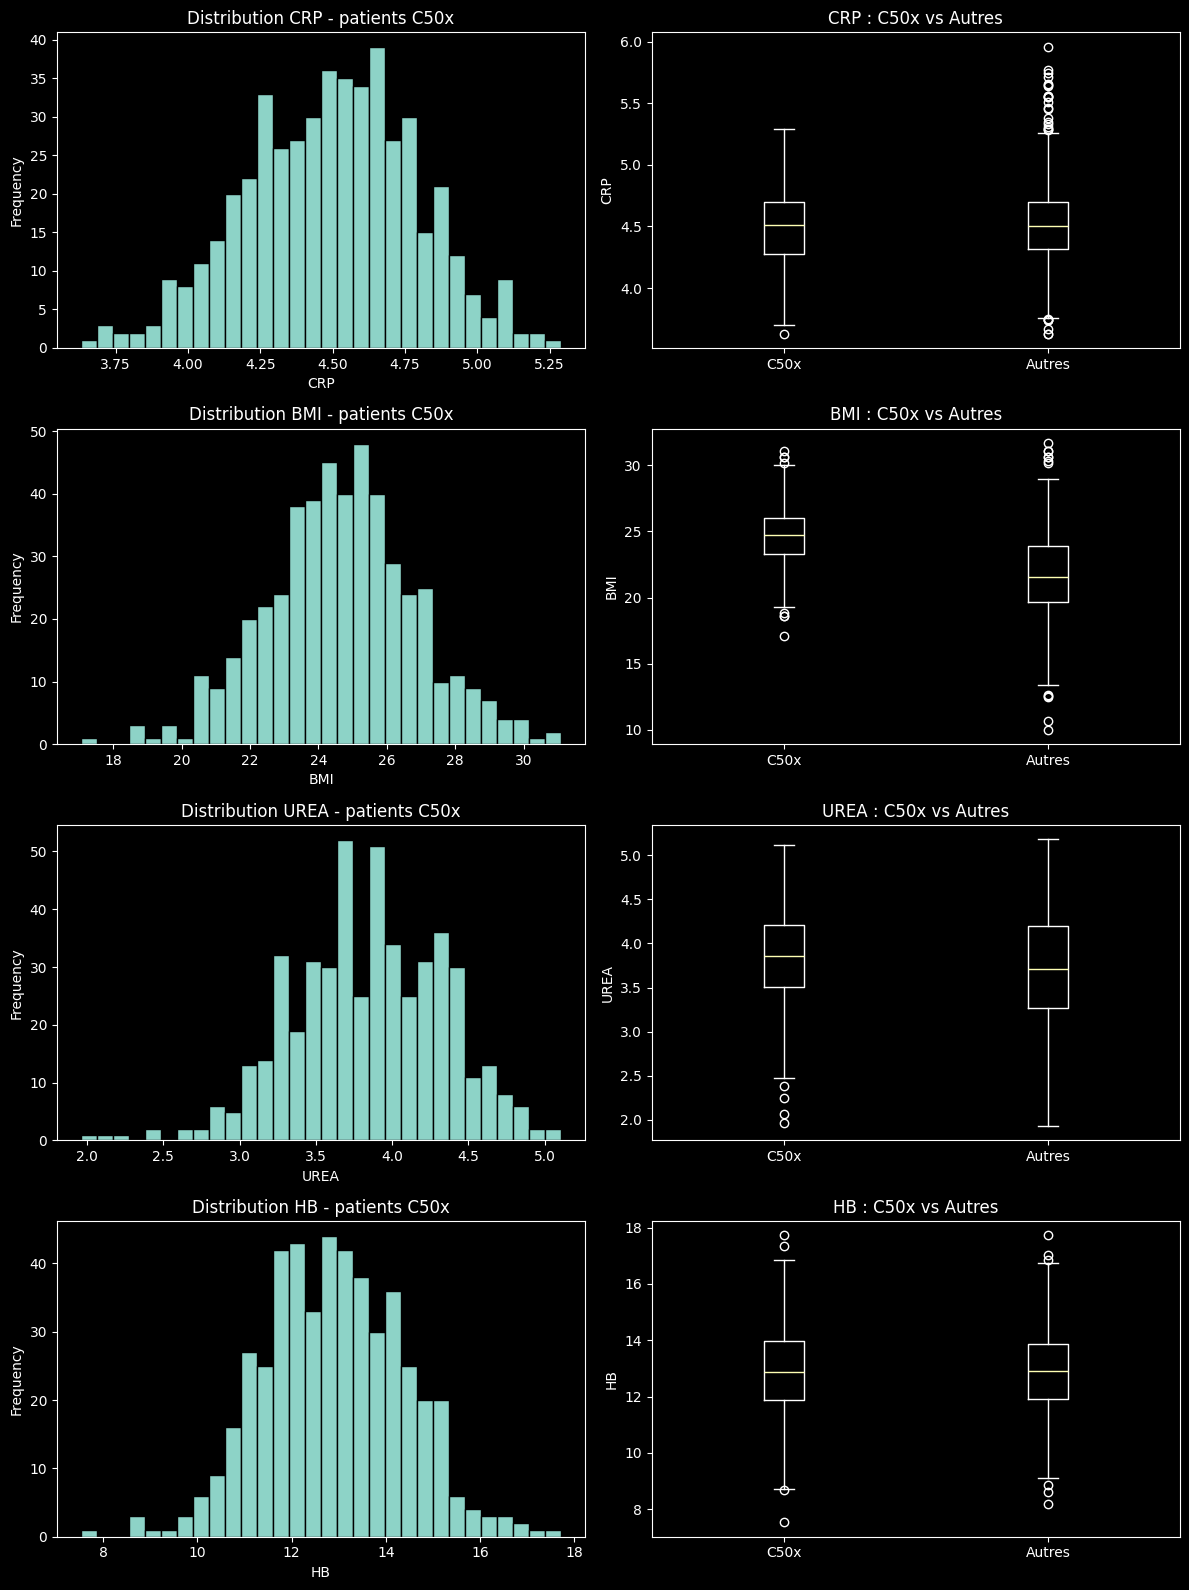

In [249]:
# Histogrammes et boxplots matplotlib pour chaque biomarqueur (C50x vs Autres)
fig, axes = plt.subplots(len(biomarqueurs), 2, figsize=(12, 4*len(biomarqueurs)))

for i, concept in enumerate(biomarqueurs):
    df_c50 = resultats[concept]['df_c50']
    df_autres = resultats[concept]['df_autres']
    
    df_c50['transformed_value'].plot.hist(bins=30, ax=axes[i, 0], edgecolor='black')
    axes[i, 0].set_title(f'Distribution {concept.upper()} - patients C50x')
    axes[i, 0].set_xlabel(concept.upper())
    
    axes[i, 1].boxplot(
        [df_c50['transformed_value'], df_autres['transformed_value']],
        labels=['C50x', 'Autres']
    )
    axes[i, 1].set_ylabel(concept.upper())
    axes[i, 1].set_title(f'{concept.upper()} : C50x vs Autres')

plt.tight_layout()
plt.show()

In [250]:
# Boxplots Altair des 4 biomarqueurs cote a cote 
df_compare_all = pd.concat([
    pd.concat([
        resultats[concept]['df_c50'].assign(groupe='C50x', concept_label=concept.upper()),
        resultats[concept]['df_autres'].assign(groupe='Autres', concept_label=concept.upper())
    ])
    for concept in biomarqueurs
])

alt.Chart(df_compare_all).mark_boxplot().encode(
    x=alt.X('groupe:N', title='Groupe'),
    y=alt.Y('transformed_value:Q', title='Valeur'),
    color='groupe:N',
    column=alt.Column('concept_label:N', title='Biomarqueur')
).properties(
    width=150,
    title='Comparaison biomarqueurs : C50x vs Autres'
).resolve_scale(y='independent')

alt.Chart(...)

In [251]:
# Chargement de la table de deduplication probabiliste (chaque paire a un score de probabilite)
df_person = pd.read_pickle("datap/df_person_fix.pkl")

df_dedup_proba = pd.read_pickle("datap/df_dedup_proba.pkl")

print(df_dedup_proba.head())
df_dedup_proba['prob'].describe()

     unique_person_id   person_id      prob
100        81076351.0  81292219.0  1.000000
48         86827620.0  87604616.0  1.000000
109        88836037.0  86178595.0  0.754593
70         84763748.0  82185488.0  1.000000
45         81097903.0  80952185.0  1.000000


count    117.000000
mean       0.693285
std        0.322495
min        0.032158
25%        0.425910
50%        0.865630
75%        1.000000
max        1.000000
Name: prob, dtype: float64

<Axes: ylabel='Density'>

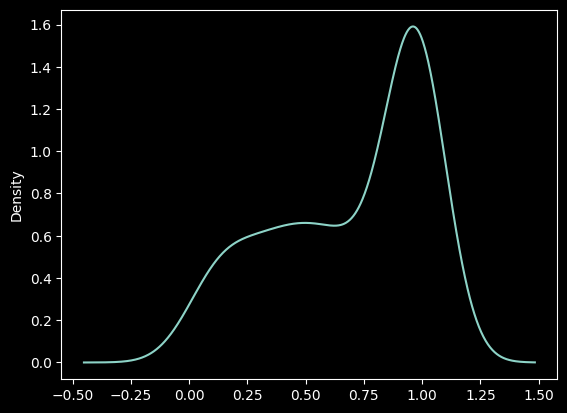

In [252]:
# Courbe de densite des scores de probabilite de deduplication
df_dedup_proba['prob'].plot.density()

In [253]:
# Fonction de deduplication probabiliste parametrable par un seuil
# Filtre les paires au-dessus du seuil, puis fusionne avec la table patients
def deduplicate_proba(df_person: pd.DataFrame, df_dedup_proba: pd.DataFrame, score: int):
    df_dedup_proba_score = df_dedup_proba[df_dedup_proba['prob'] > score]
    df_person_dedup_proba  = pd.merge(df_person, df_dedup_proba_score, on = 'person_id', how = 'outer')
    df_person_dedup_proba['unique_person_id'] = df_person_dedup_proba['unique_person_id'].fillna(df_person_dedup_proba['person_id'])
    df_person_dedup_proba = df_person_dedup_proba.drop_duplicates(['unique_person_id'], keep = 'first')
    return df_person_dedup_proba

In [254]:
# Test avec seuil  (0.90) 
df_person_dedup_proba_90 = deduplicate_proba(df_person, df_dedup_proba, score=0.90)
print(f"We have {df_person_dedup_proba_90.unique_person_id.nunique()} unique patient ids in this dataset when using the probabilistic algorithm and a threshold of 0.90.")

We have 1476 unique patient ids in this dataset when using the probabilistic algorithm and a threshold of 0.90.


In [255]:
# Test avec seuil  (0.20) 
df_person_dedup_proba_20 = deduplicate_proba(df_person, df_dedup_proba, score = 0.20)
print(f"We have {df_person_dedup_proba_20.unique_person_id.nunique()} unique patient ids in this dataset when using the probabilistic algorithm and a threshold of 0.20.")

We have 1426 unique patient ids in this dataset when using the probabilistic algorithm and a threshold of 0.20.


Text(0, 0.5, 'nombre de personnes restantes')

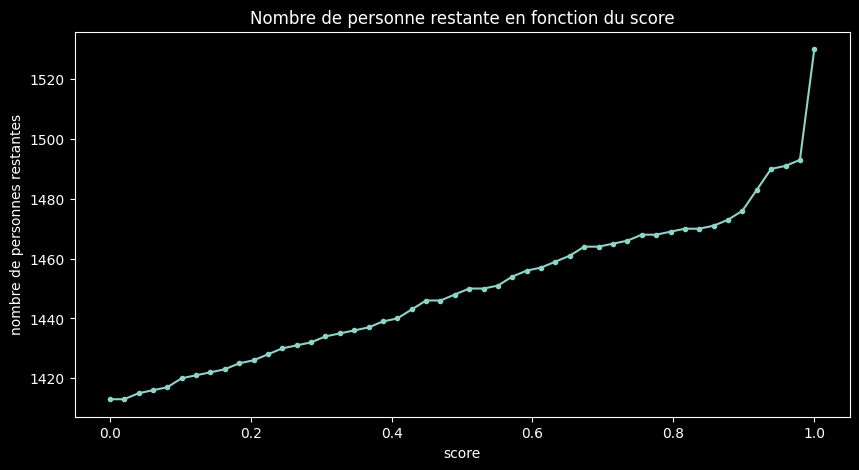

In [256]:
# Courbe du nombre de patients uniques en fonction du seuil 
threshold = np.linspace(0, 1, num=50)
n_remaining = []

for t in threshold:
    dt = deduplicate_proba(df_person, df_dedup_proba, score = t)
    n_remaining.append(dt["unique_person_id"].nunique())
    
plt.figure(figsize=(10, 5))
plt.plot(threshold, n_remaining, marker='o', markersize=3)
plt.title("Nombre de personne restante en fonction du score")
plt.xlabel("score")
plt.ylabel("nombre de personnes restantes")

Seuil optimal (elbow) : 0.980


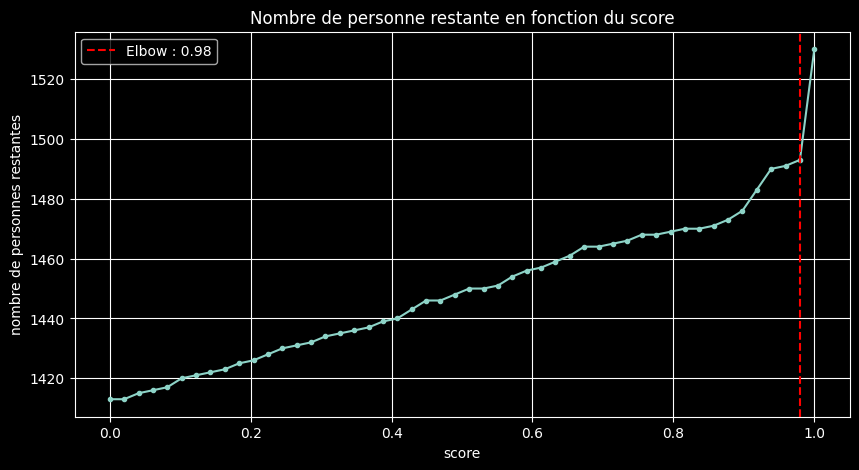

We have 1493 unique patient ids in this dataset when using the probabilistic algorithm and a the optimal threshold.


In [257]:
# Methode du coude : le point d'inflexion de la derivee seconde donne le seuil optimal
# Compromis entre faux positifs (trop de fusions) et faux negatifs (doublons non detectes)

threshold = np.linspace(0, 1, num=50)
n_remaining = []

for t in threshold:
    dt = deduplicate_proba(df_person, df_dedup_proba, score=t)
    n_remaining.append(dt["unique_person_id"].nunique())

n = np.array(n_remaining)
d2 = np.diff(np.diff(n))
elbow_idx = np.argmax(d2) + 1
optimal_threshold = threshold[elbow_idx]

print(f"Seuil optimal (elbow) : {optimal_threshold:.3f}")

plt.figure(figsize=(10, 5))
plt.plot(threshold, n_remaining, marker='o', markersize=3)
plt.axvline(x=optimal_threshold, color='red', linestyle='--',
            label=f"Elbow : {optimal_threshold:.2f}")
plt.title("Nombre de personne restante en fonction du score")
plt.xlabel("score")
plt.ylabel("nombre de personnes restantes")
plt.legend()
plt.grid(True)
plt.show()


df_person_dedup_proba_elbow = deduplicate_proba(df_person, df_dedup_proba, score = optimal_threshold)
print(f"We have {df_person_dedup_proba_elbow.unique_person_id.nunique()} unique patient ids in this dataset when using the probabilistic algorithm and a the optimal threshold.")

In [258]:
# Chargement des notes cliniques (comptes rendus medicaux) et du dataframe d'analyse
df_note = pd.read_pickle('datap/df_note.pkl')
df_analyse = pd.read_pickle('datap/df_analyse.pkl')

In [259]:
# Nombre de patients uniques dans le jeu de donnees
print(f"We have {df_person.person_id.nunique()} unique patient ids in this dataset.")

We have 1530 unique patient ids in this dataset.


In [260]:
# Comptage des patients avec plus d'une visite
df_value_count = df_analyse.person_id.value_counts()
n_numerous = df_value_count[df_value_count > 1].size
print(f"{n_numerous} patients have more than one visit")

1494 patients have more than one visit


In [261]:
# Exploration de la table des notes cliniques
df_note.info()
df_note.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547 entries, 0 to 1546
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   visit_occurrence_id  1547 non-null   float64       
 1   note_datetime        1547 non-null   datetime64[ns]
 2   note_id              1547 non-null   float64       
 3   cdm_source           1547 non-null   object        
 4   note_text            1547 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 60.6+ KB


,visit_occurrence_id,note_datetime,note_id,cdm_source,note_text
0,82113087.0,2024-02-19,83854216.0,EHR 1,
1,84162050.0,2022-12-02,87336601.0,EHR 1,Compte rendu de consultation\n\nPatient : [Nom...
2,88991591.0,2020-10-20,80825304.0,EHR 1,Compte rendu de consultation\n\nPatient : [Nom...
3,87431501.0,2020-03-29,82508858.0,EHR 1,Compte rendu de consultation\n\nPatient : [Nom...
4,80285786.0,2022-01-30,88418144.0,EHR 1,


In [262]:
# Detection des notes vides ou ne contenant que des espaces
nulls=df_note['note_text'].str.strip().fillna('').eq('').sum()
print(nulls)

613


In [263]:
# Suppression des notes vides pour ne garder que les comptes rendus exploitables
df_note_fix = df_note[df_note['note_text'].str.strip().fillna('').ne('')]

In [264]:
# Apercu d'un compte rendu aleatoire pour verifier le contenu
print(df_note_fix.sample(1)['note_text'].squeeze())

Compte rendu de consultation

Patient : [Nom du patient]
Âge : [Âge du patient]
Sexe : [Sexe du patient]
Numéro de dossier : [Numéro de dossier du patient]

Motif de la consultation:
Les résultats de la mammographie ont montré des microcalcifications, ce qui a soulevé des préoccupations quant à un possible cancer du sein. Cependant, une biopsie ultérieure a confirmé que les microcalcifications étaient non cancéreuses.

Antecedents familiaux :
Lors de l'entretien, la patiente a mentionné que plusieurs membres de sa famille, y compris ses parents et son conjoint, sont des fumeurs réguliers.

Examen du patient:
     

Signature du médecin :
[Nom du médecin]
[Titre/Spécialité]
[Hôpital/Service]


In [265]:
# Verification apres nettoyage des notes
df_note_fix.info()

<class 'pandas.core.frame.DataFrame'>
Index: 934 entries, 1 to 1541
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   visit_occurrence_id  934 non-null    float64       
 1   note_datetime        934 non-null    datetime64[ns]
 2   note_id              934 non-null    float64       
 3   cdm_source           934 non-null    object        
 4   note_text            934 non-null    object        
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 43.8+ KB


In [266]:
!pip install scikit-learn

In [267]:
# Split train (90%) / validation (10%) pour un  modele NLP
from sklearn.model_selection import train_test_split

df_note_train, df_note_val = train_test_split(
    df_note_fix,
    test_size=0.1,
    random_state=42
)

print(f"Train      : {len(df_note_train)} lignes")
print(f"Validation : {len(df_note_val)} lignes")

Train      : 840 lignes
Validation : 94 lignes


In [268]:
# Sauvegarde des ensembles train et validation en pickle
df_note_val=df_note_val.to_pickle('datap/df_note_val.pkl')
df_note_train=df_note_train.to_pickle('datap/df_note_train.pkl')

In [269]:
# Rechargement des ensembles sauvegardes
df_note_val = pd.read_pickle('datap/df_note_val.pkl')
df_note_train = pd.read_pickle('datap/df_note_train.pkl')

In [270]:
# Lecture de 25 comptes rendus pour reperer les termes lies au cancer du sein
echantillon = df_note_val.sample(n=25, random_state=42)

for idx, row in echantillon.iterrows():
    print(f"{'='*80}")
    print(f"Note ID : {row['note_id']}  |  person_id : {row.get('person_id', 'N/A')}")
    print(f"{'='*80}")
    print(row['note_text'])
    print()

Note ID : 88515330.0  |  person_id : N/A
Compte rendu de consultation

Patient : [Nom du patient]
Âge : [Âge du patient]
Sexe : [Sexe du patient]
Numéro de dossier : [Numéro de dossier du patient]

Motif de la consultation:
La patiente a été rassurée quant aux résultats négatifs de son dépistage au cancer du sein. Nous avons souligné l'importance de continuer à pratiquer des examens réguliers pour préserver sa santé mammaire.

Antecedents familiaux :
La patiente a indiqué que, du côté maternel, aucun membre de sa famille n'a jamais fumé. Ses grands-parents maternels ont toujours été non-fumeurs.

Examen du patient:
Selon les antécédents médicaux de la patiente, il n'y a aucune mention de tabagisme actif ou passé, ce qui suggère qu'elle est une non-fumeuse.

Signature du médecin :
[Nom du médecin]
[Titre/Spécialité]
[Hôpital/Service]

Note ID : 87245842.0  |  person_id : N/A
Compte rendu de consultation

Patient : [Nom du patient]
Âge : [Âge du patient]
Sexe : [Sexe du patient]
Numéro d

In [271]:
# Verification du type et contenu du dataframe de validation
print(type(df_note_val))
print(df_note_val)

<class 'pandas.core.frame.DataFrame'>
      visit_occurrence_id note_datetime     note_id cdm_source  \
530            87434102.0    2022-07-02  89544047.0      EHR 1   
124            86508822.0    2025-04-29  80003699.0      EHR 1   
350            80105823.0    2024-07-24  85067713.0      EHR 1   
892            89635444.0    2021-10-26  82650686.0      EHR 1   
1155           89350377.0    2021-10-16  87755470.0      EHR 1   
...                   ...           ...         ...        ...   
1474           88866860.0    2025-04-10  83939149.0      EHR 1   
583            87820793.0    2021-12-17  83643033.0      EHR 1   
353            84392052.0    2020-07-23  82651022.0      EHR 1   
1444           80603851.0    2021-07-20  80376274.0      EHR 1   
1458           83166532.0    2024-09-23  83797693.0      EHR 1   

                                              note_text  
530   Compte rendu de consultation\n\nPatient : [Nom...  
124   Compte rendu de consultation\n\nPatient : [Nom.

In [272]:
# Verification des colonnes disponibles
print(df_note_val.columns.tolist())

['visit_occurrence_id', 'note_datetime', 'note_id', 'cdm_source', 'note_text']


In [273]:
# Boxplot hemoglobine selon le statut vital (decede vs en vie)
df_hb = df_analyse[df_analyse['concept_source_value'] == 'hb'].copy()

df_hb['statut_vital'] = df_hb['death_datetime'].isna().map({True: 'En vie', False: 'Décédé'})

chart_vital = alt.Chart(df_hb).mark_boxplot(extent=1.5).encode(
    x=alt.X('statut_vital:N', title='Statut Vital', axis=alt.Axis(labelAngle=0)),
    y=alt.Y('transformed_value:Q', title='Hémoglobine (g/dL)'),
    color=alt.Color('statut_vital:N', legend=None, scale=alt.Scale(scheme='set2'))
).properties(
    width=600,
    height=400,
    title='Distribution de l\'hémoglobine : Décédés vs En vie'
).configure_title(
    fontSize=15,
    anchor='middle'
)

chart_vital.display()

alt.Chart(...)

In [274]:
# Boxplot age selon le statut vital
# Dedoublonnage pour ne garder qu'une ligne par patient
df_demo = df_analyse.drop_duplicates(subset=['person_id']).copy()

df_demo['birth_datetime'] = pd.to_datetime(df_demo['birth_datetime'])
df_demo['visit_start_datetime'] = pd.to_datetime(df_demo['visit_start_datetime'])

# Calcul de l'age en annees au moment de la visite
df_demo['age'] = (df_demo['visit_start_datetime'] - df_demo['birth_datetime']).dt.days / 365.25

df_demo['statut_vital'] = df_demo['death_datetime'].isna().map({True: 'En vie', False: 'Décédé'})

chart_age = alt.Chart(df_demo).mark_boxplot(extent=1.5).encode(
    x=alt.X('statut_vital:N', title='Statut Vital', axis=alt.Axis(labelAngle=0)),
    y=alt.Y('age:Q', title='Âge (années)', scale=alt.Scale(zero=False)),
    color=alt.Color('statut_vital:N', legend=None, scale=alt.Scale(scheme='set1'))
).properties(
    width=500,
    height=400,
    title='Distribution de l\'âge : Décédés vs En vie'
).configure_title(
    fontSize=15,
    anchor='middle'
)

chart_age.display()

alt.Chart(...)

In [275]:
# Import des tests statistiques pour la comparaison des cohortes
from scipy.stats import chi2_contingency, ttest_ind

In [276]:
# Selection des colonnes demographiques depuis les patients dedupliques
data = df_person_dedup_det[["person_id", "birth_datetime", "gender_source_value", "death_datetime"]]

In [277]:
# Verification de la taille du dataframe
data.shape

(1494, 4)

In [278]:
# Jointure avec les visites et calcul de l'age au moment de la visite
data = pd.merge(data, df_visit[["person_id", "visit_occurrence_id", "visit_start_datetime"]], on="person_id", how="inner")
data['age'] = (data['visit_start_datetime'] - data['birth_datetime']).dt.days / 365

In [279]:
# Variable booleenne pour le sexe feminin
data["female"] = data.gender_source_value == "female"

In [280]:
# Variable booleenne pour le statut vital (True si decede)
data["deceased"] = data.death_datetime.notna()

In [281]:
# Variable booleenne C50x : True si le patient a un diagnostic cancer du sein
codes_cibles = ['C50', 'C501', 'C502', 'C503', 'C504','C500']
c50_patients = df_condition[df_condition.condition_source_value.isin(codes_cibles)].person_id.unique()
data["C50x"] = data.person_id.isin(c50_patients)

In [282]:
# Pivot de la table biologie : format long -> format large (une colonne par biomarqueur)
bio_processed = df_bio[["visit_occurrence_id", "concept_source_value", "transformed_value"]].pivot(
    index=["visit_occurrence_id"],
    columns="concept_source_value",
    values="transformed_value"
).reset_index()
bio_processed.head()

concept_source_value,visit_occurrence_id,bmi,crp,hb,urea
0,80006041.0,20.77,4.45,11.31,4.85
1,80012467.0,23.32,3.96,12.09,3.84
2,80020085.0,23.03,4.38,13.20,4.26
3,80029349.0,25.76,4.36,15.61,3.30
4,80030416.0,21.01,4.27,15.40,3.76


In [283]:
# Jointure left pour conserver tous les patients meme sans mesures biologiques
data = pd.merge(data, bio_processed, on="visit_occurrence_id", how="left")

In [284]:
# Selection des colonnes d'interet et verification des valeurs manquantes
data = data[["person_id", "age", "female", "deceased", "bmi", "crp", "urea", "hb", "C50x"]]
data.isna().sum(axis=0)

person_id    0
age          0
female       0
deceased     0
bmi          0
crp          0
urea         0
hb           0
C50x         0
dtype: int64

In [285]:
# Restriction aux femmes uniquement pour eviter le biais de confusion lie au sexe
# Sans ce filtre, on comparerait C50x (100% femmes) a une cohorte mixte
data = data[data['female']]
df_c50x = data[data['C50x']]
df_autres = data[~data['C50x']]

In [286]:
# Effectif de la cohorte C50x
df_c50x.shape

(485, 9)

In [287]:
# Effectif de la cohorte Autres (femmes non C50x)
df_autres.shape

(468, 9)

In [288]:
# Calcul de la prevalence en pourcentage pour les variables booleennes
def prevalence(values):
    return round(values.sum()*100 / len(values),2)

In [289]:
# Calcul de la mediane et de l'intervalle interquartile pour les variables continues
def mediane_IQR(values):
    return str(round(values.median(), 2)) + ' (' + str(round(values.quantile(0.25), 2)) + '-' +  str(round(values.quantile(0.75), 2)) + ')'

In [290]:
# Dictionnaire d'agregation : mediane_IQR pour les continues, prevalence pour les booleennes
agg_dict = {
    "person_id": ["count"],
    "age": [mediane_IQR],
    "female": [prevalence],
    "deceased": [prevalence],
    "bmi": [mediane_IQR],
    "crp": [mediane_IQR],
    "hb": [mediane_IQR],
    "urea": [mediane_IQR],
}

In [291]:
# Tableau de synthese : cohortes C50x vs Autres en colonnes, variables en lignes
data_summary = data.groupby("C50x").agg(agg_dict).T
data_summary

,C50x,False,True
person_id,count,468,485
age,mediane_IQR,44.07 (23.18-64.61),62.88 (52.2-75.43)
female,prevalence,100.0,100.0
deceased,prevalence,54.91,60.21
bmi,mediane_IQR,20.58 (18.72-22.11),24.71 (23.29-25.99)
crp,mediane_IQR,4.52 (4.34-4.73),4.51 (4.28-4.7)
hb,mediane_IQR,12.8 (11.76-13.72),12.88 (11.87-13.98)
urea,mediane_IQR,3.54 (3.1-3.93),3.86 (3.51-4.21)


In [292]:
# Tests statistiques : t-test pour les variables continues, Chi2 pour les categorielles
numerical = ["age", "bmi", "crp", "hb", "urea"]
test_categorical = ["deceased"]

for feat, sub_value in data_summary.index:
    if feat in numerical:
        data_summary.loc[(feat, sub_value), "t-test"] = ttest_ind(df_autres[feat], df_c50x[feat])[1]
    if feat in test_categorical:
        data_summary.loc[(feat, sub_value), "chi-sq"] = chi2_contingency(pd.crosstab(data["C50x"], data[feat]))[1]

data_summary

,C50x,False,True,t-test,chi-sq
person_id,count,468,485,NaN,NaN
age,mediane_IQR,44.07 (23.18-64.61),62.88 (52.2-75.43),5.132843e-36,NaN
female,prevalence,100.0,100.0,NaN,NaN
deceased,prevalence,54.91,60.21,NaN,0.112515
bmi,mediane_IQR,20.58 (18.72-22.11),24.71 (23.29-25.99),1.796818e-115,NaN
crp,mediane_IQR,4.52 (4.34-4.73),4.51 (4.28-4.7),4.596432e-03,NaN
hb,mediane_IQR,12.8 (11.76-13.72),12.88 (11.87-13.98),2.983394e-01,NaN
urea,mediane_IQR,3.54 (3.1-3.93),3.86 (3.51-4.21),3.353940e-16,NaN


In [293]:
# Fusion des p-values t-test et Chi2 en une seule colonne
data_summary['p_value'] = data_summary['t-test'].fillna(data_summary['chi-sq']).apply(
    lambda p: '' if pd.isna(p) else ('< 0.0001' if p < 0.0001 else f'{p:.4f}')
)

In [294]:
# Tableau final avec renommage des colonnes pour la lisibilite
data_summary = data_summary.rename(columns={False: 'Cohorte Autres', True: 'Cohorte C50x'})
data_summary[['Cohorte Autres', 'Cohorte C50x', 'p_value']]

,C50x,Cohorte Autres,Cohorte C50x,p_value
person_id,count,468,485,
age,mediane_IQR,44.07 (23.18-64.61),62.88 (52.2-75.43),< 0.0001
female,prevalence,100.0,100.0,
deceased,prevalence,54.91,60.21,0.1125
bmi,mediane_IQR,20.58 (18.72-22.11),24.71 (23.29-25.99),< 0.0001
crp,mediane_IQR,4.52 (4.34-4.73),4.51 (4.28-4.7),0.0046
hb,mediane_IQR,12.8 (11.76-13.72),12.88 (11.87-13.98),0.2983
urea,mediane_IQR,3.54 (3.1-3.93),3.86 (3.51-4.21),< 0.0001




 Nous avons comparé 485 patientes atteintes de cancer du sein (C50x) à 468 patientes non atteintes. Les deux cohortes sont composées uniquement de femmes pour éviter un biais lié au sexe. Les patientes C50x sont significativement plus âgées (médiane 62.9 ans vs 44.1 ans, p < 0.0001) et présentent un IMC plus élevé (24.7 vs 20.6, p < 0.0001). Ces deux résultats sont cohérents avec la littérature : le cancer du sein est plus fréquent après la ménopause et le surpoids est un facteur de risque reconnu. L'urée est aussi plus élevée chez les patientes C50x (3.86 vs 3.54, p < 0.0001), L'urée est aussi plus élevée chez les patientes C50x (3.86 vs 3.54, p < 0.0001), mais cet écart peut s'expliquer par l'âge plus avancé de cette cohorte ou par l'impact des traitements anticancéreux (chimiothérapie, hormonothérapie) sur la fonction rénale. En revanche, la mortalité (p = 0.11), l'hémoglobine (p = 0.30) et la CRP (p = 0.005 mais écart de 0.01 unité) ne montrent pas de différence cliniquement pertinente entre les deux groupes. L'ajustement sur le sexe a permis de corriger un faux résultat sur la mortalité qui apparaissait significatif dans une analyse précédente avec une cohorte mixte. 